In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *

## Sanity check

In [ ]:
import numpy as np
import torch

save_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
vertex = AutoEncoderVertex24x6Dataset.load_from_file('../../../frgs_6d/tp0.020000_mu0.080000.h5')
trainer = VertexTrainer24x6(project_name='vertex_24x6', load_from=save_path)
_ = trainer.init_trainer(train_mode=TrainerModes.JUPYTER, load_from=save_path)

In [ ]:
# real sample
l, d = 24, 6
idcs = [18] * d
sample = torch.tensor(AutoEncoderVertex24x6Dataset.get_vector_from_vertex(vertex, *idcs), dtype=torch.float32)

# random value samples
torch.manual_seed(12)
r1 = torch.randn(len(sample))
r2 = torch.randn(len(sample))
r3 = torch.randn(len(sample))

# insert real values at construction axis
axis = 3  # trainer.config.construction_axis
sl = slice(axis * l, (axis +1) * l)
values_at_axis = sample[sl]
r1[sl] = values_at_axis
r2[sl] = values_at_axis
r3[sl] = values_at_axis

# predict
idcs = torch.tensor(idcs, dtype=torch.int64).to('cuda')
p_true = trainer.wrapper.predict_step((sample.reshape(1, -1).to('cuda'), [idcs]))
p1 = trainer.wrapper.predict_step((r1.reshape(1, -1).to('cuda'), [idcs]))
p2 = trainer.wrapper.predict_step((r2.reshape(1, -1).to('cuda'), [idcs]))
p3 = trainer.wrapper.predict_step((r3.reshape(1, -1).to('cuda'), [idcs]))

In [ ]:
# sum of absolute errors
(np.abs(values_at_axis - p_true.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p1.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p2.detach().cpu()[0]).sum(),
np.abs(values_at_axis - p3.detach().cpu()[0]).sum())

(tensor(0.1507), tensor(18.3892), tensor(14.5852), tensor(14.7258))

## vertex statistics

In [ ]:
data_dir = '/gpfs/data/fs71925/shepp123/frgs_6d/'
verteval.vertex_statistics(data_dir)

## correlation analysis

In [ ]:
vertex_dir = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_0/latentspaces'
cor_mat = verteval.vertex_correlation(vertex_dir=vertex_dir, pre_load_vertices=True, vertex_file_ending='npy')

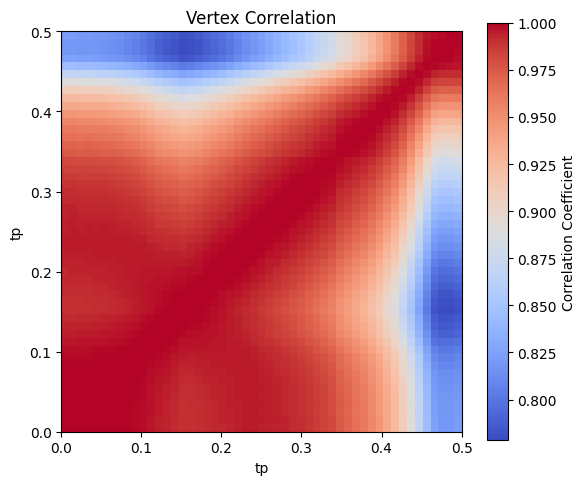

In [ ]:
vertvis.plot_correlation(cor_mat, 'Vertex Correlation')